In [21]:
# 1. Thêm các thư viện cần thiết
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential, load_model
from keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D
from keras.utils import to_categorical
from keras.datasets import cifar10

In [4]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

In [5]:
mean = np.mean(x_train,axis=(0,1,2,3))
std = np.std(x_train,axis=(0,1,2,3))
x_train = (x_train-mean)/(std+1e-7)
x_test = (x_test-mean)/(std+1e-7)

In [6]:
nClasses = 10
y_train = to_categorical(y_train,nClasses)
y_test = to_categorical(y_test,nClasses)

In [7]:
print(x_train.shape)
print(y_train.shape)

(50000, 32, 32, 3)
(50000, 10)


# Create Model

In [9]:
model = Sequential()
model.add(Conv2D(32,(3,3),padding='same',activation='relu', input_shape = (32,32,3)))
model.add(Conv2D(32,(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64,(3,3),padding='same',activation='relu'))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))

model.add(Conv2D(64,(3,3),padding='same',activation='relu'))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))

model.add(Flatten())
model.add(Dense(512,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(nClasses,activation='softmax'))



c:\laragon\bin\python\python-3.10\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [11]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 30, 30, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 15, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 13, 13, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 6, 6, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,138 (1.05 MB)

 Trainable params: 276,138 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
batch_size = 256
epochs = 20

history = model.fit(x_train,y_train,batch_size= batch_size, 
                    epochs = epochs,verbose=1,
                    validation_data=(x_test,y_test))

Epoch 1/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 36s 167ms/step - accuracy: 0.2247 - loss: 2.0170 - val_accuracy: 0.4696 - val_loss: 1.4177
Epoch 2/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 34s 171ms/step - accuracy: 0.4597 - loss: 1.4519 - val_accuracy: 0.5718 - val_loss: 1.1754
Epoch 3/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 34s 174ms/step - accuracy: 0.5661 - loss: 1.1988 - val_accuracy: 0.6383 - val_loss: 1.0094
Epoch 4/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 39s 162ms/step - accuracy: 0.6283 - loss: 1.0504 - val_accuracy: 0.6437 - val_loss: 1.0123
Epoch 5/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 34s 174ms/step - accuracy: 0.6649 - loss: 0.9407 - val_accuracy: 0.6967 - val_loss: 0.8772
Epoch 6/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 34s 172ms/step - accuracy: 0.6869 - loss: 0.8855 - val_accuracy: 0.7288 - val_loss: 0.7913
Epoch 7/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 32s 164ms/step - accuracy: 0.7105 - loss: 0.8268 - val_accuracy: 0.7422 - val_loss: 0.7372
Epoch 8/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 33s 168ms/step - accuracy: 0.7296 - loss: 0

Text(0.5, 1.0, 'Loss Curves')

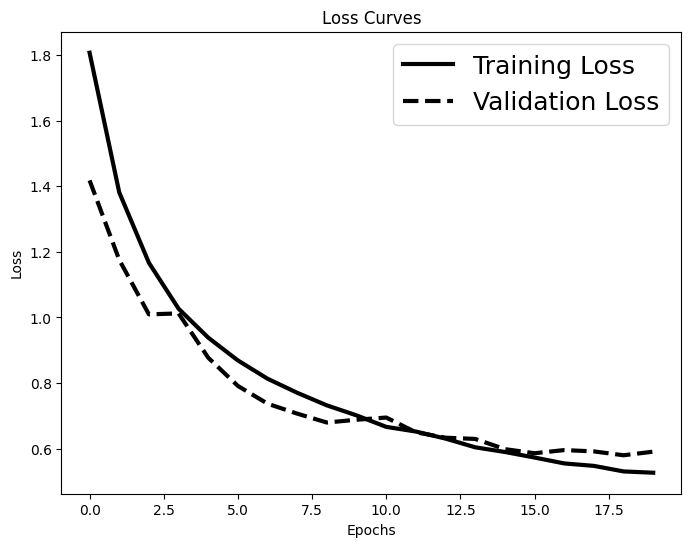

In [15]:
plt.figure(figsize=[8,6])
plt.plot(history.history['loss'], 'black', linewidth=3.0)
plt.plot(history.history['val_loss'], 'black', ls = '--',linewidth=3.0)
plt.legend(['Training Loss', 'Validation Loss'], fontsize=18)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curves")

In [13]:
model.save("modelCifar10.keras")

In [20]:
# cifar10 category label name
cifar10_labels = np.array([
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'])

In [22]:
cnn = load_model('modelCifar10.keras')

In [28]:
# Evaluate the model on test data
test_loss, test_accuracy = cnn.evaluate(x_test, y_test, verbose=0)

# Print the test loss and accuracy
print('Test Loss:', test_loss)
print('Test Accuracy:', test_accuracy)

Test Loss: 0.5910438895225525
Test Accuracy: 0.7989000082015991


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


cat


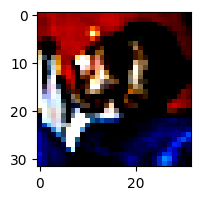

In [34]:
pred = cnn.predict(x_test[0].reshape((-1,32,32,3)))

print(cifar10_labels[np.argmax(pred)])
plt.figure(figsize=[3,2])
plt.imshow(x_test[0])
plt.show()